# Basic Retrieval-Augmented Generation (RAG)

## Overview

Retrieval-Augmented Generation (RAG) is an architecture that enhances Large Language Models (LLMs) by grounding their responses in external knowledge. Instead of relying solely on the model’s internal (and static) training data, RAG retrieves relevant information from a knowledge source at query time and uses it as context for generation.

This approach improves factual accuracy, enables access to up-to-date or proprietary data, and reduces hallucinations.

---

## Core Components

### 1. Knowledge Source

A collection of documents that contain the information you want the model to use.

Examples:

* Markdown, PDF, or HTML documents
* Database records
* Internal company documentation

These documents are usually preprocessed (cleaned and chunked) before indexing.

---

### 2. Embedding Model

An embedding model converts text into dense numerical vectors that capture semantic meaning.

* Each document chunk is embedded once during indexing
* User queries are embedded at runtime

Similarity between vectors determines relevance.

---

### 3. Vector Store (Index)

A vector database stores embeddings and supports fast similarity search.

Common choices:

* FAISS
* Pinecone
* Weaviate
* Milvus

The vector store returns the top-*k* most relevant document chunks for a query.

---

### 4. Retriever

The retriever:

1. Embeds the user query
2. Searches the vector store
3. Selects the most relevant chunks

The output is a small set of text passages used as context.

---

### 5. Generator (LLM)

The LLM receives:

* The user query
* The retrieved context

It generates a response conditioned on both, typically via a prompt template such as:

> "Answer the question using only the provided context."

---

## End-to-End Workflow

```text
User Query
    ↓
Query Embedding
    ↓
Vector Similarity Search
    ↓
Top-k Relevant Chunks
    ↓
Prompt Construction (Query + Context)
    ↓
LLM Generation
    ↓
Final Answer
```

---

## Why RAG Is Useful

* **Reduces hallucinations** by grounding responses in real data
* **Keeps knowledge current** without retraining models
* **Enables private data usage** (internal docs, manuals, policies)
* **Scales well** compared to fine-tuning for large corpora

---

## Limitations of Basic RAG

* Retrieval quality depends heavily on chunking and embeddings
* Context window limits how much information can be injected
* No reasoning over retrieved documents beyond what the LLM can infer
* Susceptible to irrelevant retrieval if similarity search is poor

---

## Common Improvements Over Basic RAG

* Hybrid search (vector + keyword)
* Re-ranking retrieved documents
* Multi-step or iterative retrieval
* Metadata filtering
* Query rewriting

---

## Summary

Basic RAG combines **retrieval** (finding relevant information) with **generation** (LLM-based answering). It is the foundation for many modern AI systems that require accuracy, transparency, and access to external knowledge.

It is simple, powerful, and often the first step toward production-grade LLM applications.


In [1]:
from typing import List, TypedDict
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

python-dotenv could not parse statement starting at line 15


True

In [2]:
docs = PyPDFLoader("grokking-deep-learning.pdf").load()

In [3]:
len(docs)

335

Without Chunking:
Document → One Vector → Vague Retrieval → Noisy Context

With Chunking:
Document → Many Focused Vectors → Precise Retrieval → Clean Context


In [4]:
# 2) Chunk
chunks = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=80).split_documents(docs)

# 3) Clean text to avoid UnicodeEncodeError (surrogates from PDF extraction)
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [5]:
len(chunks)

1424

In [7]:
# 3) Index (fresh collection each run)
embeddings = OpenAIEmbeddings(model='text-embedding-3-large')
vector_store = FAISS.from_documents(chunks, embeddings)

In [8]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [9]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [10]:
class State(TypedDict):
    question: str
    docs: List[Document]
    answer: str

In [11]:
def retrieve(state):
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In [12]:

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Answer only from the context. If not in context, say you don't know."),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)
def generate(state):
    context = "\n\n".join(d.page_content for d in state["docs"])
    out = (prompt | llm).invoke({"question": state["question"], "context": context})
    return {"answer": out.content}


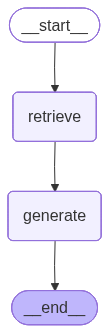

In [13]:
g = StateGraph(State)
g.add_node("retrieve", retrieve)
g.add_node("generate", generate)
g.add_edge(START, "retrieve")
g.add_edge("retrieve", "generate")
g.add_edge("generate", END)
app = g.compile()

app

In [15]:
# 5) Run
res = app.invoke({"question": "WHat is  deep learning.", "docs": [], "answer": ""})
print(res["answer"])

Deep learning is a subset of methods for machine learning that primarily uses artificial neural networks, which are algorithms inspired by the human brain. It is used in various fields such as computer vision, natural language processing, and automatic speech recognition.


In [1]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama.llms import OllamaLLM

template = """Question: {question}

Answer: Let's think step by step."""

prompt = ChatPromptTemplate.from_template(template)

model = OllamaLLM(model="llama3.1")

chain = prompt | model

chain.invoke({"question": "What is LangChain?"})

'To break down the concept of LangChain, let\'s consider what it seems to encompass:\n\n1. **Association with Human Language**: The name "LangChain" itself suggests a connection to human language, which implies that it deals with linguistic aspects or has some relation to how humans communicate through languages.\n\n2. **Potential for Complexity**: The use of the term "chain" in its name might indicate complexity or a series of connected elements. In technology and computing, chains often refer to sequences or interconnected systems.\n\n3. **Innovative Concept**: That we\'re discussing LangChain suggests it\'s an innovative idea, possibly related to artificial intelligence (AI) or natural language processing (NLP), which are areas that involve complex interactions with human language.\n\n4. **Applications in Technology and Computing**: Given the context of innovation and technology, LangChain likely has applications within the realms of AI research, NLP, or even broader fields like cog

In [3]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama.llms import OllamaLLM

template = """Question: {question}

Answer: Provide a detailed and comprehensive explanation.
"""

prompt = ChatPromptTemplate.from_template(template)

model = OllamaLLM(
    model="llama3.1",
    num_predict=2048,   # Increase max output tokens
    temperature=0.7
)

chain = prompt | model

response = chain.invoke({"question": "WHAT IS TRANSFORMER EXPLAIN IT IN DETAIL ?"})
print(response)


The Transformer! It's a groundbreaking neural network architecture that has revolutionized the field of natural language processing (NLP) and beyond. I'd be delighted to explain it in detail.

**What is a Transformer?**

A Transformer is a type of deep learning model designed for sequence-to-sequence tasks, such as machine translation, text summarization, question answering, and more. It's based on self-attention mechanisms, which allow the model to attend to different parts of an input sequence simultaneously and weigh their importance.

**Motivation Behind Transformers**

The traditional approach to NLP was based on recurrent neural networks (RNNs) or long short-term memory (LSTM) networks. However, these models have limitations when it comes to handling long-range dependencies in sequences, such as those found in natural language text. They also struggle with parallelization, making them computationally expensive.

The Transformer architecture was introduced by Vaswani et al. in 201